# Quick tutorial: building an ANI tree with sourmash

This is a short, self-contained walkthrough of the same basic workflow used throughout
`ScriptsForAnalysis/` in this repo: download genomes &rarr; sketch signatures &rarr; compute
pairwise ANI &rarr; visualize &rarr; build a tree.

We use *Cordyceps* (the entomopathogenic fungus genus that includes *C. militaris* and
relatives) here as an example genus with a good number of publicly available genome
assemblies - swap `GENUS` below for any other genus/species name to point this at a
different set of genomes.

If you re-run this yourself, NCBI's genome catalog may have added a few new assemblies
since this was last executed, so your exact genome count/tree may differ slightly.


In [1]:
## Import libraries

import subprocess
import json
import shutil
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

from Bio import Phylo
from Bio.Phylo.TreeConstruction import DistanceMatrix, DistanceTreeConstructor


In [2]:
## Configuration

DATASETS_TOOL = "/path/to/your/datasets_tool/datasets"   # NCBI datasets CLI
GENUS = "Cordyceps"

K = 21
SCALED = 1000

BASE_DIR = Path("/path/to/your/analysis_directory/Tutorial_Cordyceps_ANI")
GENOME_DIR = BASE_DIR / "genomes"
SIG_DIR = BASE_DIR / "signatures"
MATRIX_DIR = BASE_DIR / "matrices"

for d in (GENOME_DIR, SIG_DIR, MATRIX_DIR):
    d.mkdir(parents=True, exist_ok=True)


## Step 1: Download all available genomes for the genus

Query NCBI for every genome assembly under this genus, then download and extract each one.

Two things NCBI's genome catalog does that we need to handle:
- Some assemblies exist as a **GenBank/RefSeq pair** (a `GCA_...` and `GCF_...` accession pointing at the literal same assembly). We keep only the `GCA_` submission so we don't silently double-count one genome as two.
- A handful of assemblies are sometimes flagged **"atypical"** by NCBI (contamination/quality warnings). We pass `--exclude-atypical` and skip those entirely.

In [3]:
## Look up every genome assembly available for this genus

summary_cmd = [DATASETS_TOOL, "summary", "genome", "taxon", GENUS,
               "--exclude-atypical", "--as-json-lines"]
result = subprocess.run(summary_cmd, capture_output=True, text=True, check=True)

records = [json.loads(line) for line in result.stdout.splitlines()]

genomes = {}
for r in records:
    acc = r["accession"]
    if not acc.startswith("GCA_"):
        # Skip GCF_ (RefSeq) entries - each one is paired with a GCA_ (GenBank) accession
        # for the exact same underlying assembly, so keeping both would double-count genomes.
        continue
    organism = r["organism"]["organism_name"]
    genomes[acc] = organism

print(f"Found {len(genomes)} unique, non-atypical genome assemblies for {GENUS}:")
for acc, organism in genomes.items():
    print(f"  {acc}\t{organism}")


Found 86 unique, non-atypical genome assemblies for Cordyceps:
  GCA_051528895.1	Cordyceps amoene-rosea
  GCA_047651725.1	Cordyceps blackwelliae
  GCA_056505955.1	Cordyceps cateniannulata
  GCA_028828415.1	Cordyceps cateniannulata
  GCA_030411435.1	Cordyceps cateniannulata
  GCA_030411495.1	Cordyceps cateniannulata
  GCA_030785045.1	Cordyceps cateniannulata
  GCA_030789085.1	Cordyceps cateniannulata
  GCA_030789605.1	Cordyceps cateniannulata
  GCA_043643355.1	Cordyceps chanhua
  GCA_050574885.1	Cordyceps cicadae
  GCA_002968875.1	Cordyceps cicadae
  GCA_010211705.1	Cordyceps cicadae
  GCA_056776755.1	Cordyceps cicadae
  GCA_057381015.1	Cordyceps cicadae
  GCA_057381055.1	Cordyceps cicadae
  GCA_001644785.1	Cordyceps cicadae BA-001
  GCA_056915225.1	Cordyceps farinosa
  GCA_000733625.1	Cordyceps farinosa
  GCA_003025275.1	Cordyceps farinosa
  GCA_030778385.1	Cordyceps farinosa
  GCA_030779685.1	Cordyceps farinosa
  GCA_030783605.1	Cordyceps farinosa
  GCA_030783945.1	Cordyceps farinosa


In [4]:
## Download and extract each genome, renaming to <ACCESSION>_genomic.fna

for acc in genomes:
    fna_out = GENOME_DIR / f"{acc}_genomic.fna"
    if fna_out.exists():
        print(f"{acc}: already downloaded, skipping")
        continue

    zip_path = BASE_DIR / f"{acc}.zip"
    download_cmd = [DATASETS_TOOL, "download", "genome", "accession", acc,
                     "--filename", str(zip_path), "--exclude-atypical"]

    # NCBI occasionally drops a connection under back-to-back requests, so retry
    # a couple of times before giving up on an accession.
    for attempt in range(3):
        proc = subprocess.run(download_cmd, capture_output=True, text=True)
        if proc.returncode == 0:
            break
        print(f"{acc}: download attempt {attempt + 1} failed, retrying...")
        time.sleep(5)
    else:
        print(f"{acc}: FAILED after 3 attempts, skipping")
        continue

    extract_dir = BASE_DIR / f"extract_{acc}"
    shutil.unpack_archive(str(zip_path), str(extract_dir), format="zip")

    fna_src = next((extract_dir / "ncbi_dataset" / "data" / acc).glob("*.fna"))
    shutil.copy(fna_src, fna_out)

    shutil.rmtree(extract_dir)
    zip_path.unlink()
    print(f"{acc}: downloaded and extracted")

fna_files = sorted(GENOME_DIR.glob("*_genomic.fna"))
print(f"\n{len(fna_files)} genomes ready in {GENOME_DIR}")


GCA_051528895.1: downloaded and extracted


GCA_047651725.1: downloaded and extracted


GCA_056505955.1: downloaded and extracted


GCA_028828415.1: downloaded and extracted


GCA_030411435.1: downloaded and extracted


...

GCA_051527835.1: downloaded and extracted


GCA_002591385.1: downloaded and extracted


GCA_025583755.1: downloaded and extracted


GCA_003025305.1: downloaded and extracted


GCA_051528795.1: downloaded and extracted

86 genomes ready in /path/to/your/analysis_directory/Tutorial_Cordyceps_ANI/genomes


## Step 2: Compute sourmash signatures

Sketch each genome assembly into a MinHash signature at a single k-mer size/scaled value.

In [5]:
## Sketch a sourmash signature for every genome

for fna_file in fna_files:
    sig_path = SIG_DIR / f"{fna_file.stem}_k{K}.sig"
    if sig_path.exists():
        continue
    cmd = f"sourmash sketch dna -p k={K},scaled={SCALED} {fna_file} -o {sig_path}"
    subprocess.run(cmd, shell=True, check=True, capture_output=True)

sig_files = sorted(SIG_DIR.glob(f"*_k{K}.sig"))
print(f"Computed {len(sig_files)} signatures in {SIG_DIR}")


Computed 86 signatures in /path/to/your/analysis_directory/Tutorial_Cordyceps_ANI/signatures


## Step 3: Compute pairwise ANI

`sourmash compare` builds an all-by-all similarity matrix from the signatures directly; passing `--ani` converts the raw Jaccard/containment values into an ANI estimate.

In [6]:
## Compute the pairwise ANI matrix

sig_list_file = MATRIX_DIR / "all_signatures.txt"
with open(sig_list_file, "w") as f:
    for sig_file in sig_files:
        f.write(f"{sig_file}\n")

matrix_out = MATRIX_DIR / f"ani_k{K}.npy"
compare_cmd = (f"sourmash compare --from-file {sig_list_file} -k {K} --ani --quiet -o {matrix_out}")
subprocess.run(compare_cmd, shell=True, check=True, capture_output=True)
print(f"ANI matrix saved to: {matrix_out}")

ani_matrix = np.load(matrix_out)

labels_file = Path(str(matrix_out) + ".labels.txt")
with open(labels_file) as f:
    raw_labels = [line.strip() for line in f]

# sourmash labels each row/column with the signature filepath - parse back out just the accession
accessions = ["_".join(Path(label).stem.split("_")[:2]) for label in raw_labels]
display_labels = [f"{genomes[acc]} ({acc})" for acc in accessions]

ani_df = pd.DataFrame(ani_matrix, index=display_labels, columns=display_labels)
ani_df.round(4)


ANI matrix saved to: /path/to/your/analysis_directory/Tutorial_Cordyceps_ANI/matrices/ani_k21.npy


,Cordyceps javanica (GCA_030780405.1),Cordyceps javanica (GCA_030781225.1),Cordyceps javanica (GCA_030782525.1),Cordyceps farinosa (GCA_000733625.1),Cordyceps javanica (GCA_030780535.1),Cordyceps cateniannulata (GCA_030411495.1),Cordyceps cicadae (GCA_057381015.1),Cordyceps javanica (GCA_030778025.1),Cordyceps javanica (GCA_030780585.1),Cordyceps javanica (GCA_030780045.1),...,Cordyceps javanica (GCA_030778125.1),Cordyceps javanica (GCA_030780145.1),Cordyceps farinosa (GCA_056915225.1),Cordyceps sp. D1 (GCA_051527835.1),Cordyceps gunnii (GCA_052399015.1),Cordyceps javanica (GCA_030780445.1),Cordyceps javanica (GCA_051527875.1),Cordyceps blackwelliae (GCA_047651725.1),Cordyceps javanica (GCA_006981975.1),Cordyceps javanica (GCA_030781285.1)
Cordyceps javanica (GCA_030780405.1),1.0000,0.9997,0.9921,0.9914,0.9997,0.8262,0.8200,0.9878,0.9997,0.9995,...,0.9807,0.9997,0.8340,0.8342,0.7312,0.9996,0.9896,0.8191,0.9917,0.9900
Cordyceps javanica (GCA_030781225.1),0.9997,1.0000,0.9920,0.9914,0.9997,0.8261,0.8197,0.9878,0.9997,0.9995,...,0.9807,0.9997,0.8341,0.8345,0.7312,0.9996,0.9897,0.8191,0.9917,0.9899
Cordyceps javanica (GCA_030782525.1),0.9921,0.9920,1.0000,0.9910,0.9920,0.8260,0.8175,0.9879,0.9920,0.9920,...,0.9800,0.9921,0.8327,0.8347,0.7310,0.9920,0.9894,0.8183,0.9912,0.9924
Cordyceps farinosa (GCA_000733625.1),0.9914,0.9914,0.9910,1.0000,0.9913,0.8246,0.8190,0.9884,0.9913,0.9912,...,0.9808,0.9913,0.8333,0.8341,0.7332,0.9912,0.9895,0.8200,0.9908,0.9909
Cordyceps javanica (GCA_030780535.1),0.9997,0.9997,0.9920,0.9913,1.0000,0.8261,0.8199,0.9878,0.9997,0.9995,...,0.9807,0.9997,0.8341,0.8342,0.7312,0.9996,0.9896,0.8189,0.9917,0.9899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cordyceps javanica (GCA_030780445.1),0.9996,0.9996,0.9920,0.9912,0.9996,0.8258,0.8199,0.9877,0.9996,0.9995,...,0.9807,0.9997,0.8343,0.8340,0.7312,1.0000,0.9895,0.8184,0.9916,0.9899
Cordyceps javanica (GCA_051527875.1),0.9896,0.9897,0.9894,0.9895,0.9896,0.8249,0.8186,0.9873,0.9896,0.9896,...,0.9794,0.9896,0.8323,0.8334,0.7290,0.9895,1.0000,0.8191,0.9900,0.9893
Cordyceps blackwelliae (GCA_047651725.1),0.8191,0.8191,0.8183,0.8200,0.8189,0.8542,0.9291,0.8180,0.8189,0.8188,...,0.8190,0.8186,0.8183,0.8292,0.7303,0.8184,0.8191,1.0000,0.8182,0.8189
Cordyceps javanica (GCA_006981975.1),0.9917,0.9917,0.9912,0.9908,0.9917,0.8261,0.8186,0.9883,0.9917,0.9916,...,0.9804,0.9917,0.8344,0.8352,0.7320,0.9916,0.9900,0.8182,1.0000,0.9901


## Step 4: Heatmap of pairwise ANI

Reorder the rows/columns by average-linkage clustering on the same ANI-derived distances used for the tree in the next step, then plot the heatmap.

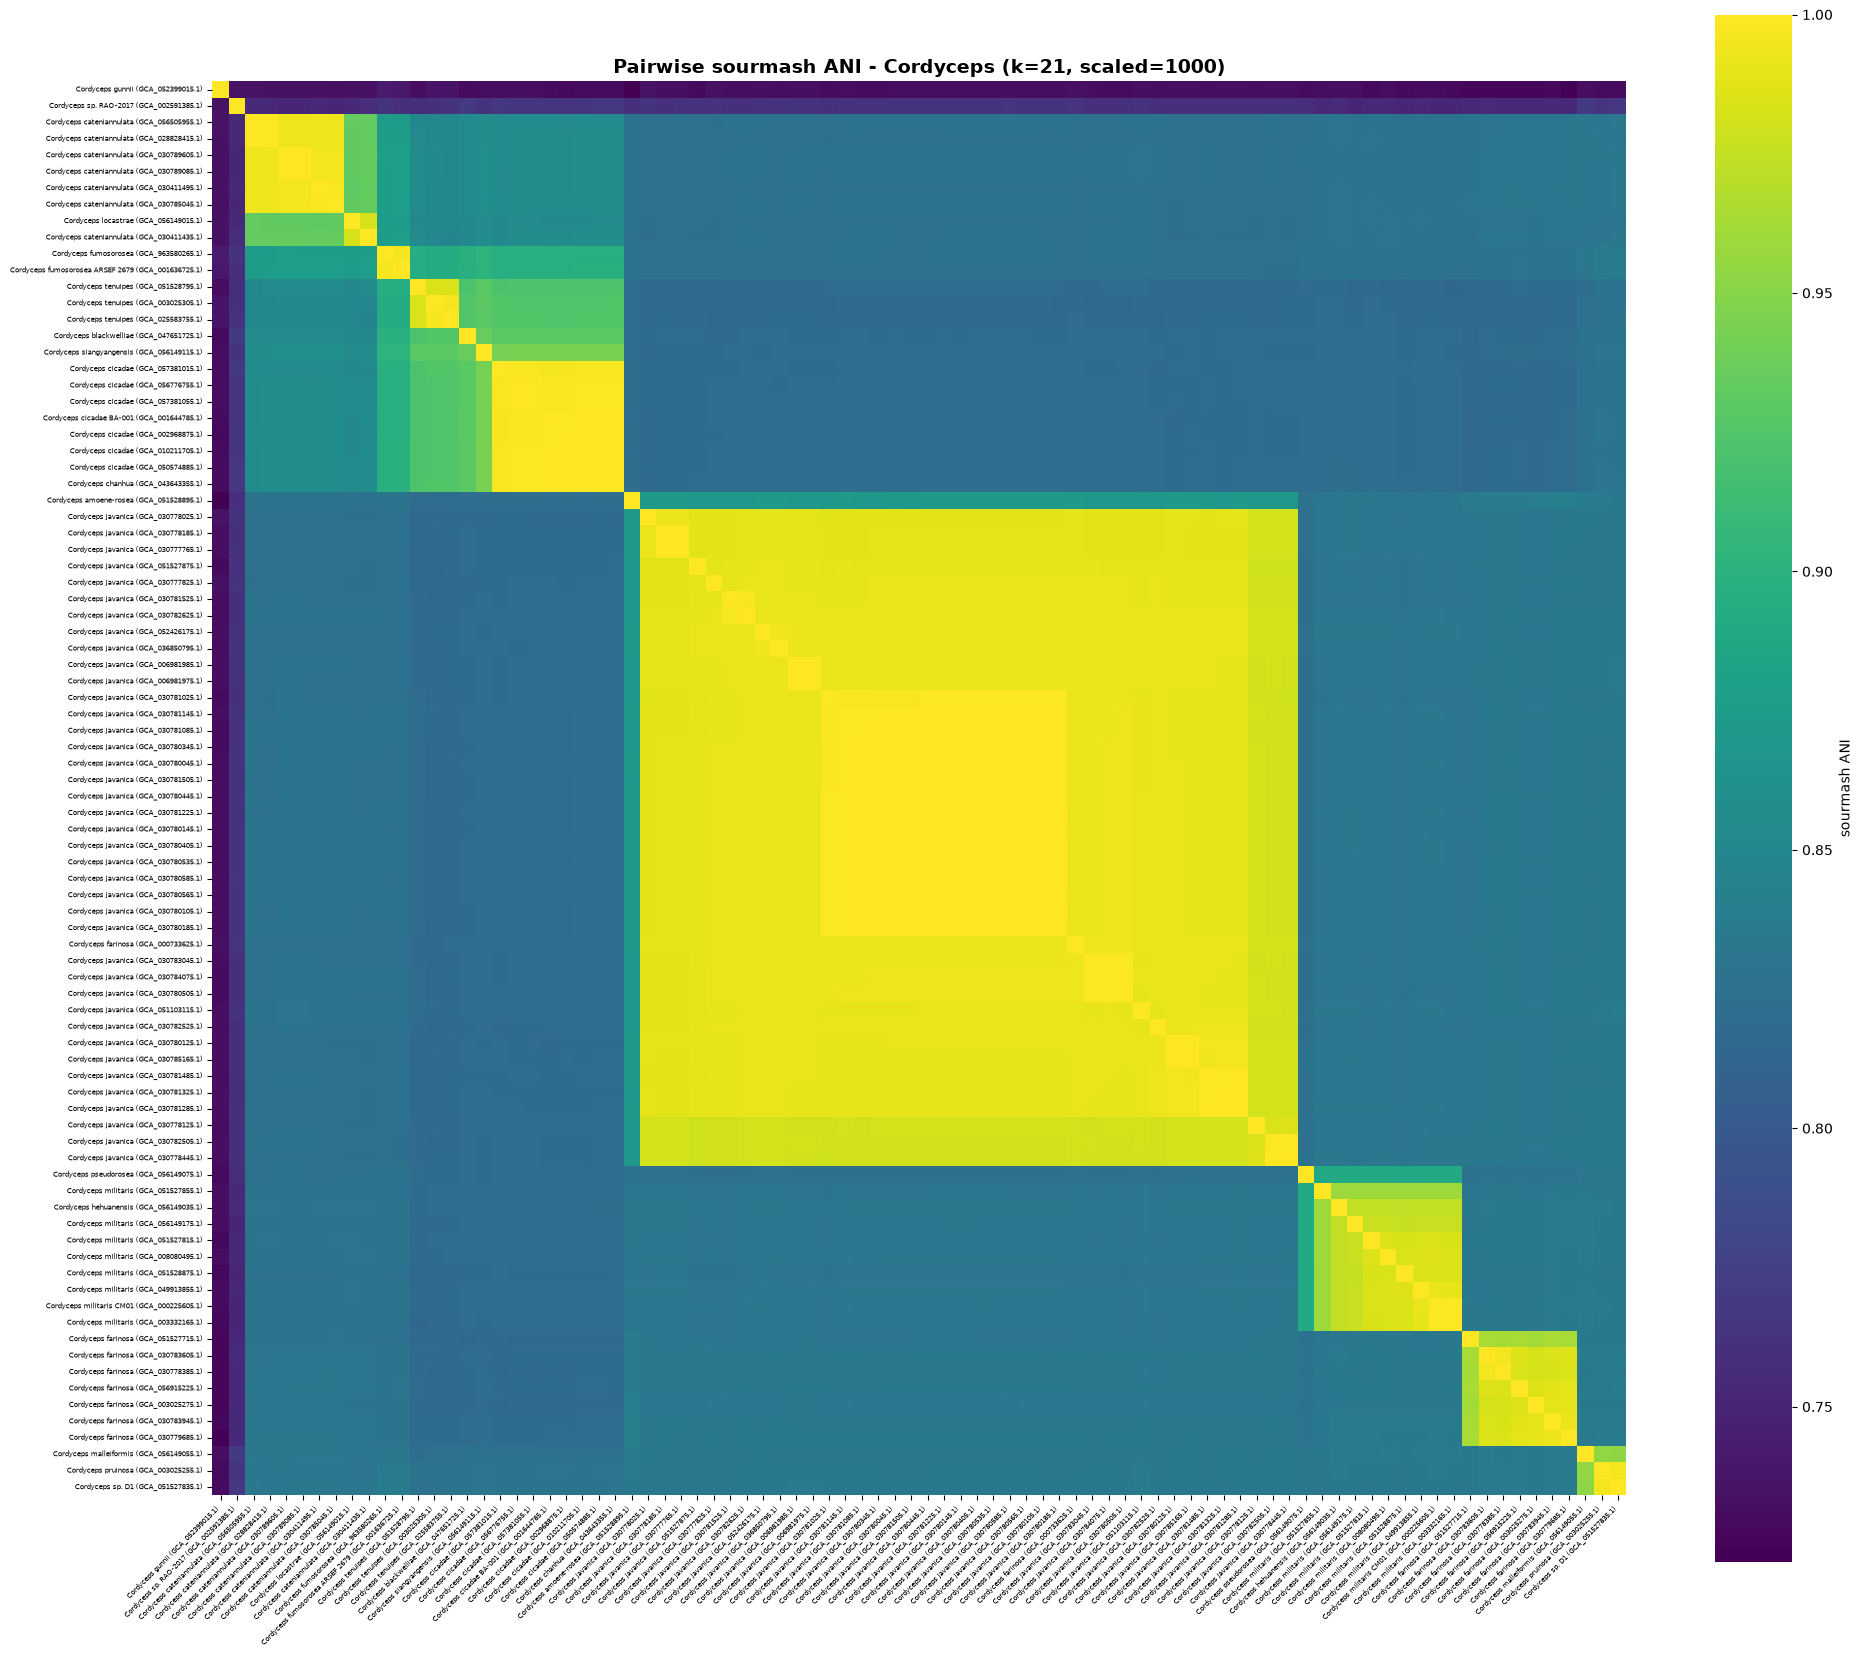

In [7]:
## Reorder genomes by average-linkage clustering, then plot the ANI heatmap

condensed_dist = squareform(1 - ani_matrix, checks=False)
linkage_matrix = linkage(condensed_dist, method="average")
order = leaves_list(linkage_matrix)

ani_df_ordered = ani_df.iloc[order, order]

fig, ax = plt.subplots(figsize=(20, 17))
sns.heatmap(ani_df_ordered, cmap="viridis", vmin=ani_df.values.min(), vmax=1.0,
            square=True, xticklabels=True, yticklabels=True,
            cbar_kws={"label": "sourmash ANI"}, ax=ax)
ax.set_title(f"Pairwise sourmash ANI - {GENUS} (k={K}, scaled={SCALED})", fontsize=14, fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=5)
plt.setp(ax.get_yticklabels(), fontsize=5)
plt.tight_layout()
plt.show()


## Step 5: Build a UPGMA tree

Convert the ANI matrix to a distance matrix (`1 - ANI`) and cluster it with UPGMA, the same approach used for the sourmash trees throughout this repo.

Tree saved to: /path/to/your/analysis_directory/Tutorial_Cordyceps_ANI/matrices/upgma_tree_k21.newick


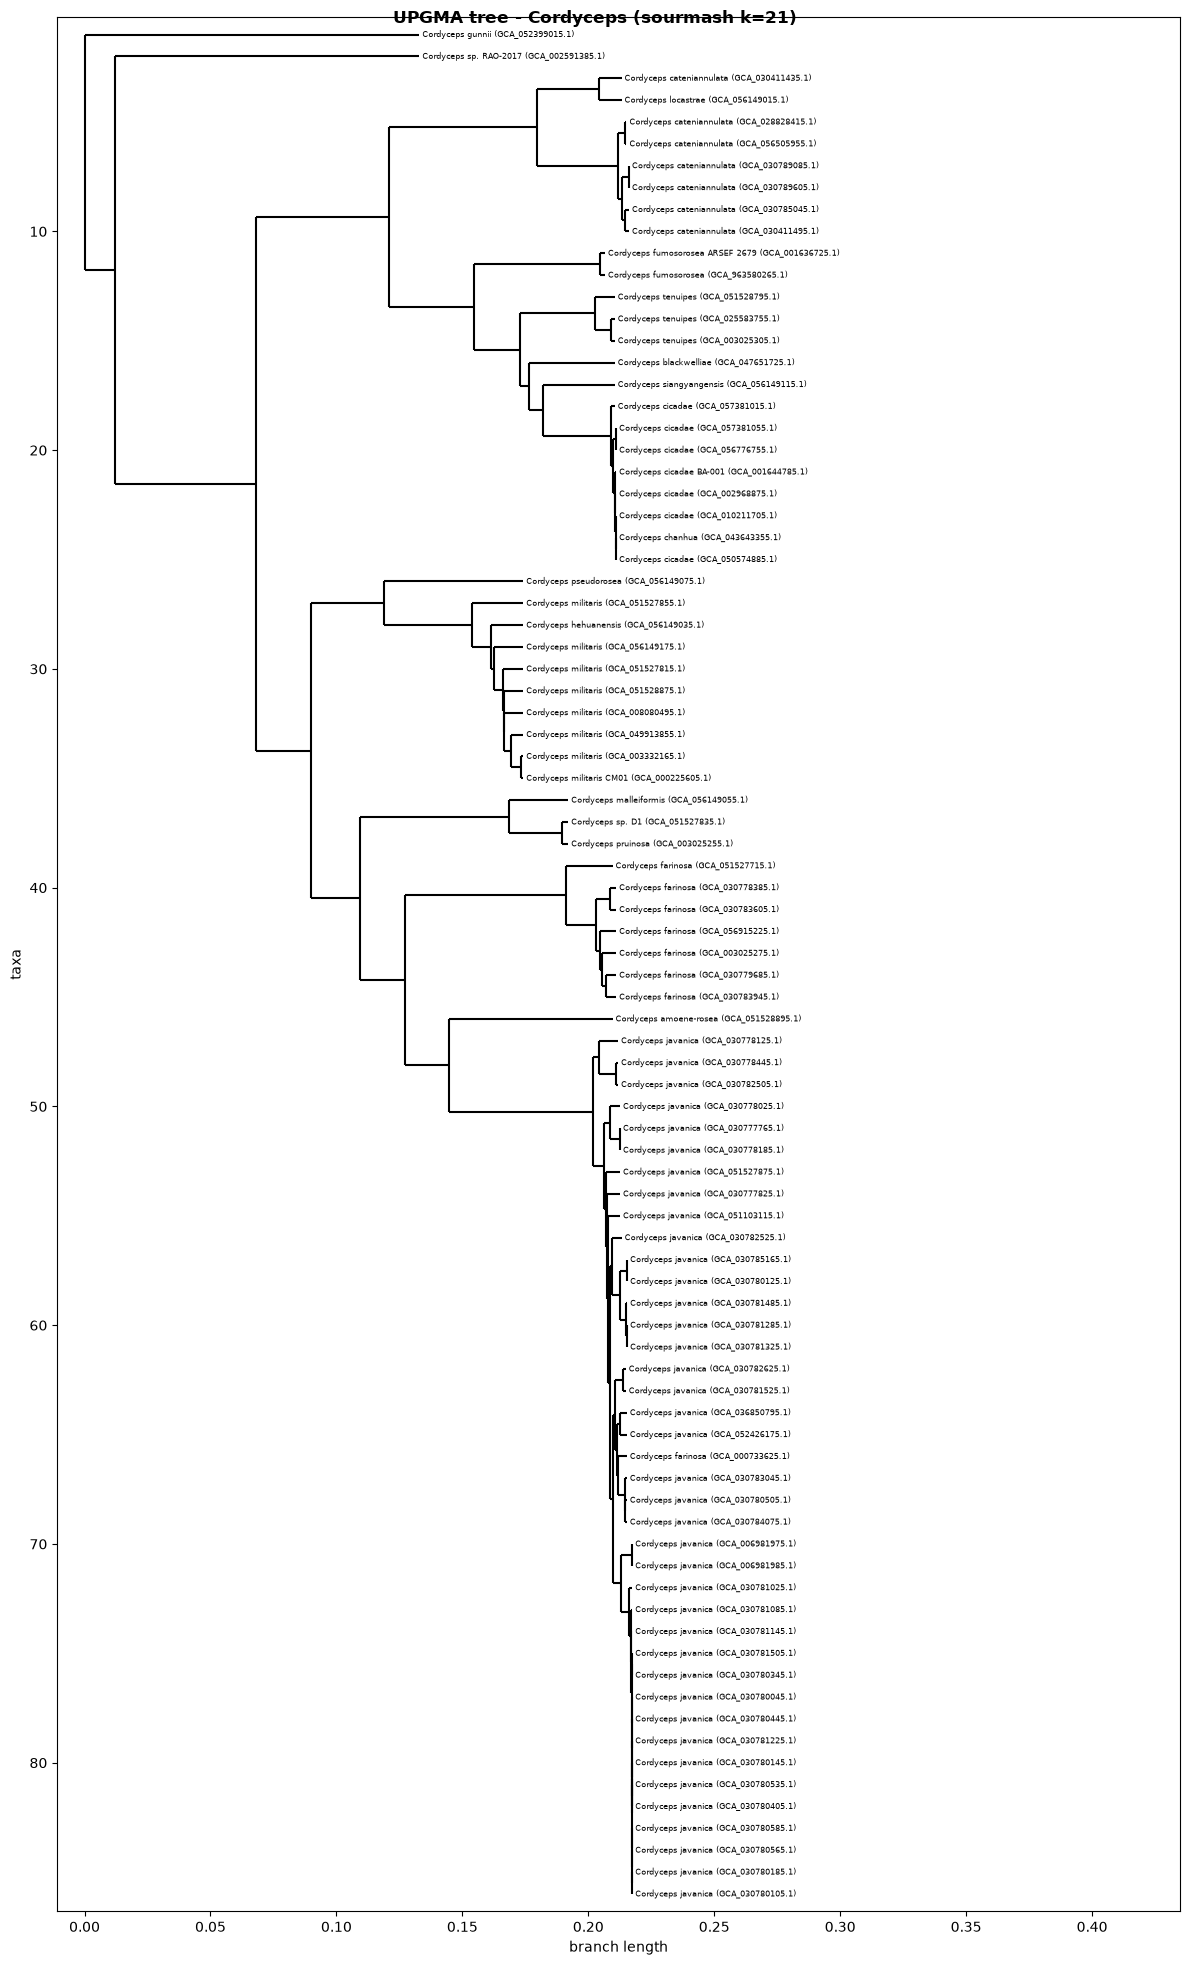

In [8]:
## Build and draw a UPGMA tree from the ANI-derived distances

dist_matrix_full = 1 - ani_matrix

# BioPython's DistanceMatrix wants a lower-triangular condensed matrix
condensed = [dist_matrix_full[i, :i + 1].tolist() for i in range(len(dist_matrix_full))]
bio_dist_matrix = DistanceMatrix(names=display_labels, matrix=condensed)

constructor = DistanceTreeConstructor()
upgma_tree = constructor.upgma(bio_dist_matrix)
upgma_tree.ladderize()

tree_out = MATRIX_DIR / f"upgma_tree_k{K}.newick"
Phylo.write(upgma_tree, str(tree_out), "newick")
print(f"Tree saved to: {tree_out}")

def hide_inner_labels(clade):
    return clade.name if clade.is_terminal() else None

fig = plt.figure(figsize=(12, 20))
ax = fig.add_subplot(1, 1, 1)
Phylo.draw(upgma_tree, axes=ax, do_show=False, label_func=hide_inner_labels)
for text in ax.texts:
    text.set_fontsize(6)
ax.set_xlim(right=ax.get_xlim()[1] * 1.6)  # leave room for full tip labels
fig.suptitle(f"UPGMA tree - {GENUS} (sourmash k={K})", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
